Completion and Compliance
====

Metrics and stats for completion and compliance rates

In [1]:
import os

%load_ext autoreload
%autoreload 2

img_dir = "outputs/imgs/quantitative/"
if not os.path.exists(img_dir):
    os.makedirs(img_dir)

In [2]:
"""
Read the data

"""

from analysis_utils import clean

meal_info = clean.cleaned_smartwatch(keep_catchups=False, keep_day0=False)
meal_info.head()

/home/mh19137/seaco_smartwatch_paper/analysis_utils/clean.py:156: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Normal' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  copy.loc[start_time, col_name] = "Normal"
/home/mh19137/seaco_smartwatch_paper/analysis_utils/clean.py:227: UserWarning: Long catchup: not marking Meal at 2022-05-19 09:02:49 as catchup
  warnings.warn(


 Open ended catchup at 2022-02-11 20:02:05 ended by No response at 2022-02-12 08:02:11
 Open ended catchup at 2022-02-14 20:26:30 ended by No response at 2022-02-15 08:02:16
 Open ended catchup at 2022-04-19 08:01:14 ended by No catch-up at 2022-04-19 08:01:17
 Open ended catchup at 2022-06-27 15:53:14 ended by Catch-up start at 2022-06-27 15:54:06
 Open ended catchup at 2021-12-31 22:11:10 ended by No catch-up at 2022-01-01 08:01:15
 Open ended catchup at 2022-05-24 07:25:36 ended by Catch-up start at 2022-05-24 07:26:00
 Open ended catchup at 2022-03-21 08:01:57 ended by No catch-up at 2022-03-21 08:02:04
 Open ended catchup at 2022-03-07 18:33:30 ended by No catch-up at 2022-03-07 18:33:34
 Open ended catchup at 2022-03-07 18:37:08 ended by No catch-up at 2022-03-07 18:37:14
 Open ended catchup at 2022-03-07 19:29:23 ended by No response at 2022-03-08 08:02:56
 Open ended catchup at 2022-03-08 08:30:40 ended by No catch-up at 2022-03-08 08:31:08
 Open ended catchup at 2022-03-08 09:

,x_id,meal_type,portion_size,utensil,location,week_day,p_id,ramadanstart,ramadanend,delta,catchup_category,catchup_flag,entry_in_ramadan,early_stop,first_in_ramadan,last_in_ramadan,all_in_ramadan,any_in_ramadan
Datetime,,,,,,,,,,,,,,,,,,
2021-11-03 09:00:43,17,Meal,Large,Fork/spoon,Home,Wednesday,16231,03apr2022,01may2022,1 days 09:00:43,NaN,False,False,False,False,False,False,False
2021-11-03 09:00:49,18,Drink,Large,No response,Home,Wednesday,16231,03apr2022,01may2022,1 days 09:00:49,NaN,False,False,False,False,False,False,False
2021-11-03 10:01:03,19,Meal,Large,Fork/spoon,Home,Wednesday,16231,03apr2022,01may2022,1 days 10:01:03,NaN,False,False,False,False,False,False,False
2021-11-03 11:01:07,20,No food/drink,No response,No response,No response,Wednesday,16231,03apr2022,01may2022,1 days 11:01:07,NaN,False,False,False,False,False,False,False
2021-11-03 12:01:16,21,Drink,Mid-size,No response,Home,Wednesday,16231,03apr2022,01may2022,1 days 12:01:16,NaN,False,False,False,False,False,False,False


In [7]:
"""
Collapse entries into a bool

"""

meal_info["entry"] = meal_info["meal_type"].isin(
    {"Meal", "Drink", "Snack", "No food/drink"}
)

In [8]:
"""
Define a cutoff for meal length

"""

import numpy as np
import pandas as pd


# Find the average and maximum number of entries per participant
def collapse_meal_info(meal_df: pd.DataFrame, delta: pd.Timedelta) -> pd.DataFrame:
    collapsed_meal_info = pd.DataFrame()

    for p_id, group in meal_df.groupby("p_id"):
        assert group.index.is_monotonic_increasing

        # Mark which ones are near enough each other to be considered the same
        n_entries = len(group)
        keep = np.ones(n_entries, dtype=bool)

        for i in range(1, n_entries):
            if (group.index[i] - group.index[i - 1] < delta) and (
                group["entry"].iloc[i] == group["entry"].iloc[i - 1]
            ):
                keep[i] = False

        # Append to the new dataframe
        collapsed_meal_info = pd.concat([collapsed_meal_info, group[keep]])

    return collapsed_meal_info

In [31]:
deltas = pd.timedelta_range(start="1min", end="60min", freq="1min")

collapsed_meal_infos = [collapse_meal_info(meal_info, delta) for delta in deltas]

# Number of entries per participant per day
avg_entries_per_day = [
    len(collapsed_meal_info) / (7 * meal_info["p_id"].unique().size)
    for collapsed_meal_info in collapsed_meal_infos
]

# Maximum entries
max_entries_per_day = []
for collapsed_meal_info in collapsed_meal_infos:
    collapsed_meal_info["date"] = collapsed_meal_info.index.date

    max_entries_per_day.append(
        collapsed_meal_info.groupby(["p_id", "date"]).size().max()
    )

In [32]:
time_cutoff_min = 27

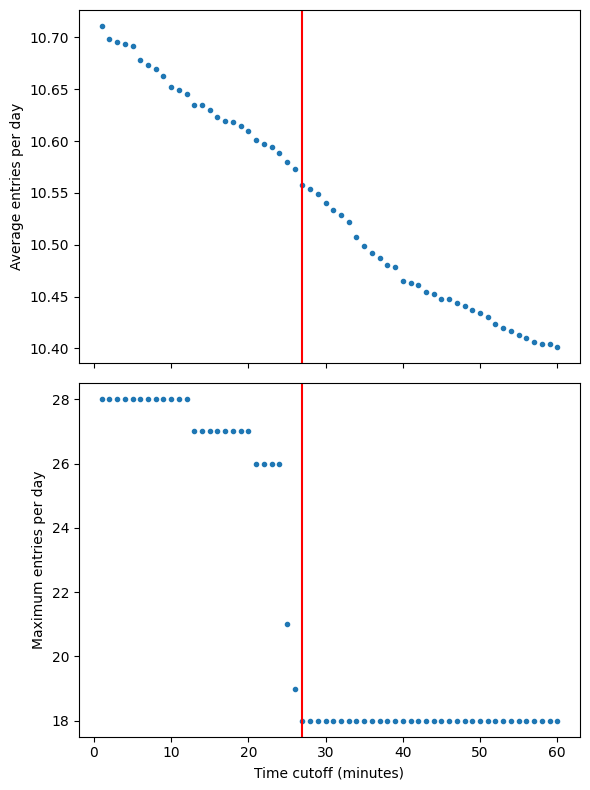

In [149]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(6, 8), sharex=True)

axes[0].plot(deltas.total_seconds() / 60, avg_entries_per_day, ".")
axes[1].plot(deltas.total_seconds() / 60, max_entries_per_day, ".")

axes[0].set_ylabel("Average entries per day")
axes[1].set_ylabel("Maximum entries per day")

axes[1].set_xlabel("Time cutoff (minutes)")

for axis in axes:
    axis.axvline(time_cutoff_min, color="r")

fig.tight_layout()
fig.savefig(f"{img_dir}/entries_vs_time_cutoff.png")

In [34]:
compliance_df = collapse_meal_info(meal_info, pd.Timedelta(minutes=time_cutoff_min))
compliance_df.head()

,x_id,meal_type,portion_size,utensil,location,week_day,p_id,ramadanstart,ramadanend,delta,catchup_category,catchup_flag,entry_in_ramadan,early_stop,first_in_ramadan,last_in_ramadan,all_in_ramadan,any_in_ramadan,entry
Datetime,,,,,,,,,,,,,,,,,,,
2022-04-09 08:02:16,306,No response,No response,No response,No response,Saturday,141,03apr2022,01may2022,1 days 08:02:16,NaN,False,True,False,True,True,True,True,False
2022-04-09 09:02:24,307,No food/drink,No response,No response,No response,Saturday,141,03apr2022,01may2022,1 days 09:02:24,NaN,False,True,False,True,True,True,True,True
2022-04-09 10:04:24,308,No response,No response,No response,No response,Saturday,141,03apr2022,01may2022,1 days 10:04:24,NaN,False,True,False,True,True,True,True,False
2022-04-09 11:04:28,309,No food/drink,No response,No response,No response,Saturday,141,03apr2022,01may2022,1 days 11:04:28,NaN,False,True,False,True,True,True,True,True
2022-04-09 12:04:32,310,No food/drink,No response,No response,No response,Saturday,141,03apr2022,01may2022,1 days 12:04:32,NaN,False,True,False,True,True,True,True,True


In [35]:
"""
Compliance rate for all participants

"""

# Group by days
collapsed_meal_info["delta_day"] = collapsed_meal_info["delta"].dt.days

n_participants, n_days = len(collapsed_meal_info["p_id"].unique()), 7

# Find how many entries each participant made on each day
n_entries = np.zeros((n_participants, n_days), dtype=int)
n_positive = np.zeros((n_participants, n_days), dtype=int)
for i, (p_id, group) in enumerate(collapsed_meal_info.groupby("p_id")):
    for j, (delta, subgroup) in enumerate(group.groupby("delta_day")):
        n_entries[i, j] = len(subgroup["entry"])
        n_positive[i, j] = subgroup["entry"].sum()

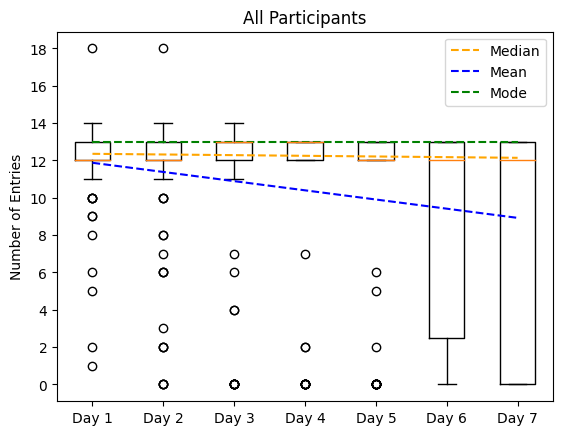

In [71]:
from matplotlib.ticker import MaxNLocator

n_participants, n_days = n_entries.shape

# Create a list of entries for each day
entries_per_day = [n_entries[:, i] for i in range(n_days)]

# Create a list of day labels
d = np.arange(1, 8, 1)
days = ["Day {}".format(i) for i in d]

# Create the boxplot
fig, axis = plt.subplots()

axis.boxplot(entries_per_day, labels=days)

# Plot medians and means
median_vals = np.polyval(
    np.polyfit(
        np.arange(0, n_days, 1),
        [np.median(entries) for entries in entries_per_day],
        1,
    ),
    d,
)
axis.plot(d, median_vals, "--", label="Median", color="orange")

# Plot means
mean_vals = np.polyval(
    np.polyfit(
        np.arange(1, n_days + 1, 1),
        [np.mean(entries) for entries in entries_per_day],
        1,
    ),
    d,
)
axis.plot(d, mean_vals, "b--", label="Mean")

mode_vals = np.polyval(
    np.polyfit(
        np.arange(1, n_days + 1, 1),
        [np.argmax(np.bincount(entries)) for entries in entries_per_day],
        1,
    ),
    d,
)
axis.plot(d, mode_vals, "g--", label="Mode")

axis.set_ylabel("Number of Entries")
axis.set_title("All Participants")

axis.yaxis.set_major_locator(MaxNLocator(integer=True))

axis.legend()
fig.savefig(f"{img_dir}/n_entries_day_boxplot.png")

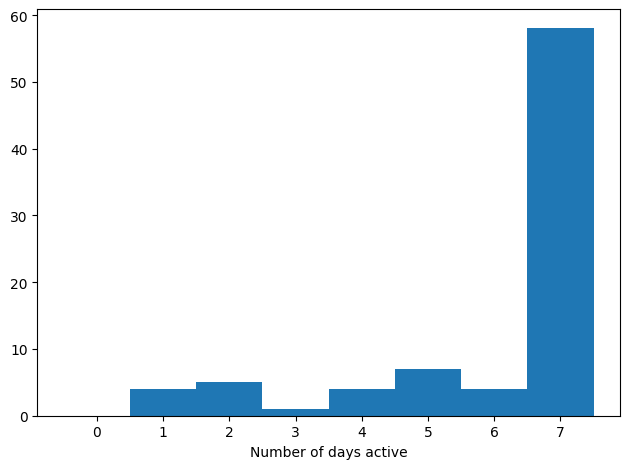

In [51]:
"""
Compliance rate for active participants

"""


# Find how many days each participant was active for
# A participant is considered inactive if they have 0 entries on this and all subsequent days
# e.g. [13, 13, 13, 13, 12, 0, 0] is active for 5 days
def active_days(entries: np.ndarray) -> int:
    return len(entries) - np.argmax(np.cumsum(entries[::-1]) > 0)


n_days_active = np.array([active_days(entries) for entries in n_entries])

fig, axis = plt.subplots()
axis.hist(n_days_active, bins=np.arange(0, 9, 1) - 0.5)

axis.set_xlabel("Number of days active")
fig.tight_layout()
fig.savefig(f"{img_dir}/n_days_active_hist.png")

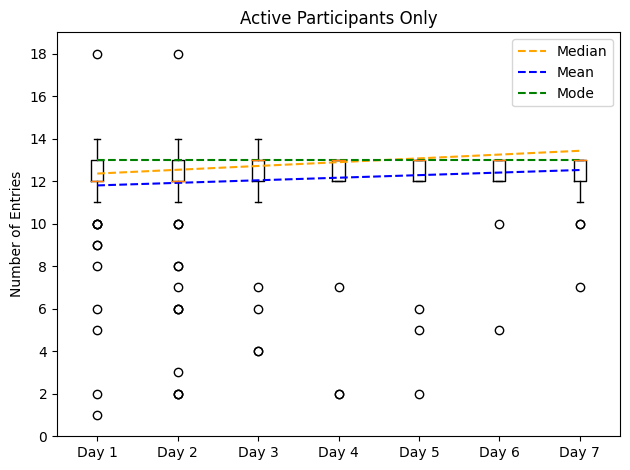

In [73]:
# On each day, take only the active participants and plot a boxplot of their entries
# I'm fairly sure this is the same thing as just removing the zeros from the above boxplot, but that's fine
fig, axis = plt.subplots()

medians = []
means = []
modes = []
for day, entries in zip(d, n_entries.T):
    # A participant is active on this day if n_days_active
    active_participants = n_days_active - day >= 0

    axis.boxplot(entries[active_participants], positions=[day])

    medians.append(np.median(entries[active_participants]))
    means.append(np.mean(entries[active_participants]))
    modes.append(np.argmax(np.bincount(entries[active_participants])))

median_vals = np.polyval(
    np.polyfit(
        np.arange(0, n_days, 1),
        medians,
        1,
    ),
    d,
)
axis.plot(d, median_vals, "--", label="Median", color="orange")

# Plot means
mean_vals = np.polyval(
    np.polyfit(
        np.arange(1, n_days + 1, 1),
        means,
        1,
    ),
    d,
)
axis.plot(d, mean_vals, "b--", label="Mean")

mode_vals = np.polyval(
    np.polyfit(
        np.arange(1, n_days + 1, 1),
        modes,
        1,
    ),
    d,
)
axis.plot(d, mode_vals, "g--", label="Mode")

axis.legend()
axis.set_ylim(0, np.max(n_entries.flat) + 1)

axis.set_ylabel("Number of Entries")
axis.set_title("Active Participants Only")

axis.yaxis.set_major_locator(MaxNLocator(integer=True))
axis.set_xticks(d, days)

fig.tight_layout()

fig.savefig(f"{img_dir}/n_entries_day_boxplot_active_users.png")

/tmp/ipykernel_3827/3267082968.py:6: RuntimeWarning: invalid value encountered in divide
  completion_rate = n_positive / n_entries


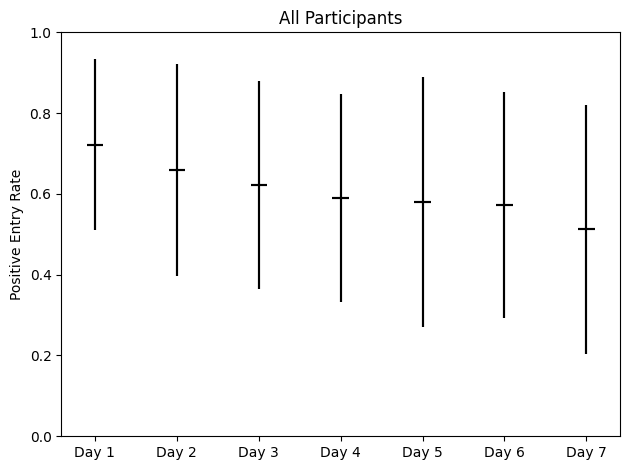

In [137]:
"""
Completion rate

"""

completion_rate = n_positive / n_entries

fig, axis = plt.subplots()

all_positive_rate = []
all_positive_rate_std = []
for rate, day in zip(completion_rate.T, d):
    rate = rate[~np.isnan(rate)]

    mean = np.mean(rate)
    std = np.std(rate)

    axis.errorbar([day, day], [mean, mean], yerr=std, xerr=0.1, fmt="k-")

    all_positive_rate.append(mean)
    all_positive_rate_std.append(std)


axis.set_xticks(d, days)
axis.set_ylim(0, 1)

axis.set_ylabel("Positive Entry Rate")
axis.set_title("All Participants")

fig.tight_layout()
fig.savefig(f"{img_dir}/completion_rate.png")

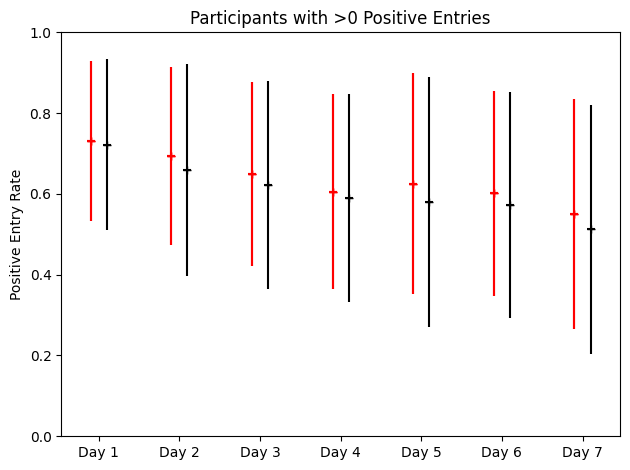

In [148]:
"""
Plot the positive entry rate excluding those who made 0 positive entries

"""

fig, axis = plt.subplots()

offset = 0.1  # How much to offset the error bars
n_zero = []
for day, entries, positive in zip(d, n_entries.T, n_positive.T):
    # Mask for participants who made 0 positive entries
    nonzero_positive = positive != 0
    n_zero.append(np.sum(~nonzero_positive))

    positive_rate = positive[nonzero_positive] / entries[nonzero_positive]

    # Find the positivity rate
    mean = np.mean(positive_rate)
    std = np.std(positive_rate)

    axis.errorbar(
        [day - offset, day - offset],
        [mean, mean],
        yerr=std,
        xerr=offset / 2,
        fmt="r+",
    )

axis.errorbar(
    d + offset, all_positive_rate, yerr=all_positive_rate_std, xerr=offset / 2, fmt="k+"
)

axis.set_xticks(d, days)
axis.set_ylim(0, 1)

axis.set_ylabel("Positive Entry Rate")
axis.set_title("Participants with >0 Positive Entries")

fig.tight_layout()
fig.savefig(f"{img_dir}/completion_rate_no_zeros.png")

In [ ]:
"""
Number of participants who made 0 positive entries
"""